In [1]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

import sys
sys.path.insert(0, '/home/ferjao_k/sw/aare/build')
from aare import fit_scurve, fit_scurve2, fit_scurve_minuit, fit_scurve2_minuit, fit_scurve_minuit_grad, fit_scurve2_minuit_grad

## Model curves

In [2]:
def scurve(x, p): # rising Scurve
    p0, p1, p2, p3, p4, p5 = p
    return (p0 + p1*x) + 0.5 *(1 + erf((x-p2) / (np.sqrt(2)*p3))) * (p4 + p5*(x-p2))

def scurve2(x, p): #falling Scurve
    p0, p1, p2, p3, p4, p5 = p
    return (p0 + p1*x) + 0.5 *(1 - erf((x-p2) / (np.sqrt(2)*p3))) * (p4 + p5*(x-p2))

## Generate data (1D)

In [3]:
x = np.linspace(0,120, 121)

rng = np.random.default_rng(42)
0
p_true_rising = np.array([100.0, 0.25, 60.0, 6.0, 120.0,  1.0])
p_true_falling = np.array([100.0, 0.25, 60.0, 6.0, 120.0, -1.0])

y_true_rising = scurve(x, p_true_rising)
y_true_falling = scurve2(x, p_true_falling)

noise_sigma = 4

y_rising = y_true_rising + rng.normal(0, noise_sigma, size=x.shape)
# y_err_r = np.full_like(x, noise_sigma)

y_falling = y_true_falling + rng.normal(0, noise_sigma, size=x.shape)
# y_err_f = np.full_like(x, noise_sigma)

## Plot synthetic data

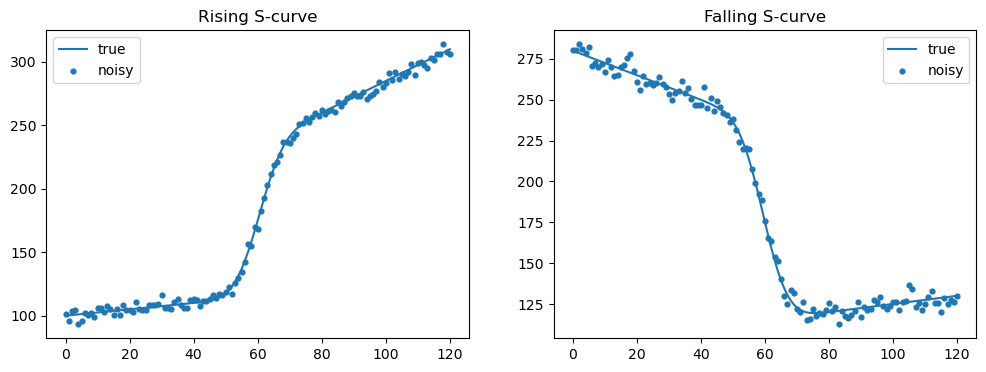

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12,4), sharex=True)

ax[0].plot(x, y_true_rising, label="true")
ax[0].scatter(x, y_rising, s=12, label="noisy")
ax[0].set_title("Rising S-curve")
ax[0].legend()

ax[1].plot(x, y_true_falling, label="true")
ax[1].scatter(x, y_falling, s=12, label="noisy")
ax[1].set_title("Falling S-curve")
ax[1].legend()

plt.show()

## Fit the Rising S-curve

In [5]:
res_r_lmfit = fit_scurve(x, y_rising)
res_r_minuit = fit_scurve_minuit(x, y_rising)
res_r_minuit_grad = fit_scurve_minuit_grad(x, y_rising)

print("True rising params:         ", p_true_rising)
print("lmfit rising result:        ", res_r_lmfit)
print("minuit rising result:       ", res_r_minuit[:-1])
print("minuit_grad rising result:  ", res_r_minuit_grad[:-1])

True rising params:          [100.     0.25  60.     6.   120.     1.  ]
lmfit rising result:         [ 99.46783104   0.28701685  60.07840507   5.71546071 117.25793891
   0.96723356]
minuit rising result:        [ 99.46795493   0.28701227  60.07843667   5.7154553  117.25835059
   0.96723277]
minuit_grad rising result:   [ 99.46795493   0.28701227  60.07843667   5.7154553  117.2583506
   0.96723277]


## Fit the Falling S-curve

In [6]:
res_f_lmfit = fit_scurve2(x, y_falling)
res_f_minuit = fit_scurve2_minuit(x, y_falling)
res_f_minuit_grad = fit_scurve2_minuit_grad(x, y_falling)

print("True falling params:  ", p_true_falling)
print("lmfit falling result:  ", res_f_lmfit)
print("minuit falling result:  ", res_f_minuit[:-1])
print("minuit_grad falling result:  ", res_f_minuit_grad[:-1])

True falling params:   [100.     0.25  60.     6.   120.    -1.  ]
lmfit falling result:   [101.73447899   0.2257864   60.25197087   6.09291484 118.47673528
  -0.99867704]
minuit falling result:   [101.73561862   0.22577771  60.25195788   6.09264041 118.47565075
  -0.99868055]
minuit_grad falling result:   [101.73561859   0.22577771  60.25195788   6.09264042 118.47565078
  -0.99868055]


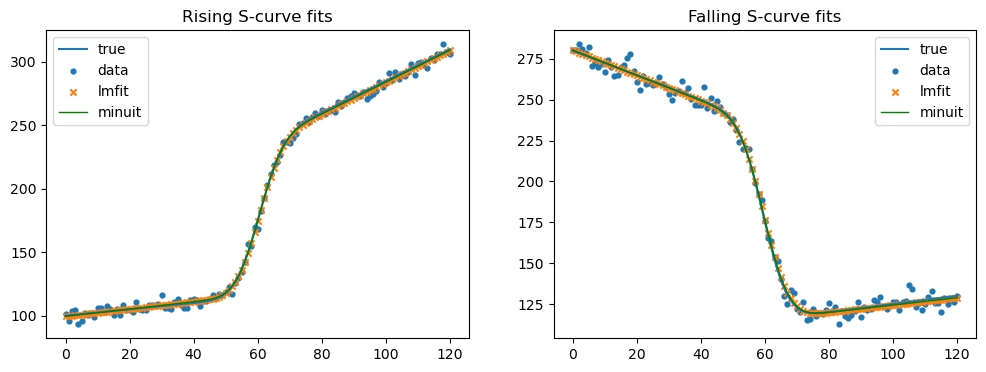

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

# rising
ax[0].plot(x, y_true_rising, label="true")
ax[0].scatter(x, y_rising, s=12, label="data")
ax[0].scatter(x, scurve(x, res_r_lmfit[:6]), s=20, marker="x", label="lmfit")
ax[0].plot(x, scurve(x, res_r_minuit[:6]), linewidth=1, color="green", label="minuit")
ax[0].set_title("Rising S-curve fits")
ax[0].legend()

# falling
ax[1].plot(x, y_true_falling, label="true")
ax[1].scatter(x, y_falling, s=12, label="data")
ax[1].scatter(x, scurve2(x, res_f_lmfit[:6]), s=20, marker="x", label="lmfit")
ax[1].plot(x, scurve2(x, res_f_minuit[:6]), linewidth=1, color="green", label="minuit")
ax[1].set_title("Falling S-curve fits")
ax[1].legend()

plt.show()

## Quick error check

In [8]:
print("Rising abs error lmfit : ", np.abs(res_r_lmfit[:6] - p_true_rising))
print("Rising abs error minuit: ", np.abs(res_r_minuit[:6] - p_true_rising))
print("Rising abs error minuit_grad: ", np.abs(res_r_minuit_grad[:6] - p_true_rising))
print("\n")
print("Falling abs error lmfit : ", np.abs(res_f_lmfit[:6] - p_true_falling))
print("Falling abs error minuit: ", np.abs(res_f_minuit[:6] - p_true_falling))
print("Falling abs error minuit_grad: ", np.abs(res_f_minuit_grad[:6] - p_true_falling))

Rising abs error lmfit :  [0.53216896 0.03701685 0.07840507 0.28453929 2.74206109 0.03276644]
Rising abs error minuit:  [0.53204507 0.03701227 0.07843667 0.2845447  2.74164941 0.03276723]
Rising abs error minuit_grad:  [0.53204507 0.03701227 0.07843667 0.2845447  2.7416494  0.03276723]


Falling abs error lmfit :  [1.73447899e+00 2.42135973e-02 2.51970871e-01 9.29148384e-02
 1.52326472e+00 1.32296033e-03]
Falling abs error minuit:  [1.73561862e+00 2.42222908e-02 2.51957877e-01 9.26404085e-02
 1.52434925e+00 1.31944689e-03]
Falling abs error minuit_grad:  [1.73561859e+00 2.42222905e-02 2.51957878e-01 9.26404154e-02
 1.52434922e+00 1.31944714e-03]


## Benchmark

In [9]:
def bench(fn, x, y, n_repeats=200):
    # warmup runs
    fn(x, y)
    fn(x, y)
    fn(x, y)
    
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        res = fn(x, y)
    t1 = time.perf_counter()
    return (t1-t0)/n_repeats

t_r_lmfit  = bench(fit_scurve, x, y_rising)
t_r_minuit = bench(fit_scurve_minuit, x, y_rising)
t_r_minuit_grad = bench(fit_scurve_minuit_grad, x, y_rising)

t_f_lmfit  = bench(fit_scurve2, x, y_falling)
t_f_minuit = bench(fit_scurve2_minuit, x, y_falling)
t_f_minuit_grad = bench(fit_scurve2_minuit_grad, x, y_falling)

print(f"Rising  lmfit : {1e3*t_r_lmfit:.3f} ms")
print(f"Rising  minuit: {1e3*t_r_minuit:.3f} ms")
print(f"Rising  minuit_grad: {1e3*t_r_minuit_grad:.3f} ms")
print("\n")
print(f"Falling lmfit : {1e3*t_f_lmfit:.3f} ms")
print(f"Falling minuit: {1e3*t_f_minuit:.3f} ms")
print(f"Falling minuit_grad: {1e3*t_f_minuit_grad:.3f} ms")

Rising  lmfit : 0.631 ms
Rising  minuit: 1.085 ms
Rising  minuit_grad: 0.331 ms


Falling lmfit : 0.417 ms
Falling minuit: 1.097 ms
Falling minuit_grad: 0.311 ms
